In [1]:
!pip install easyocr
!pip install opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 11.4 MB/s eta 0:00:00


In [4]:
from google.colab import files

uploaded = files.upload()

Saving train.jpg to train.jpg


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


RAILWAY STATION (1.00)
4 (0.65)
alal (0.63)
Image ID: 2G4XWAI (0.72)
alamy (1.00)
WWW. (0.53)
alamycom (1.00)


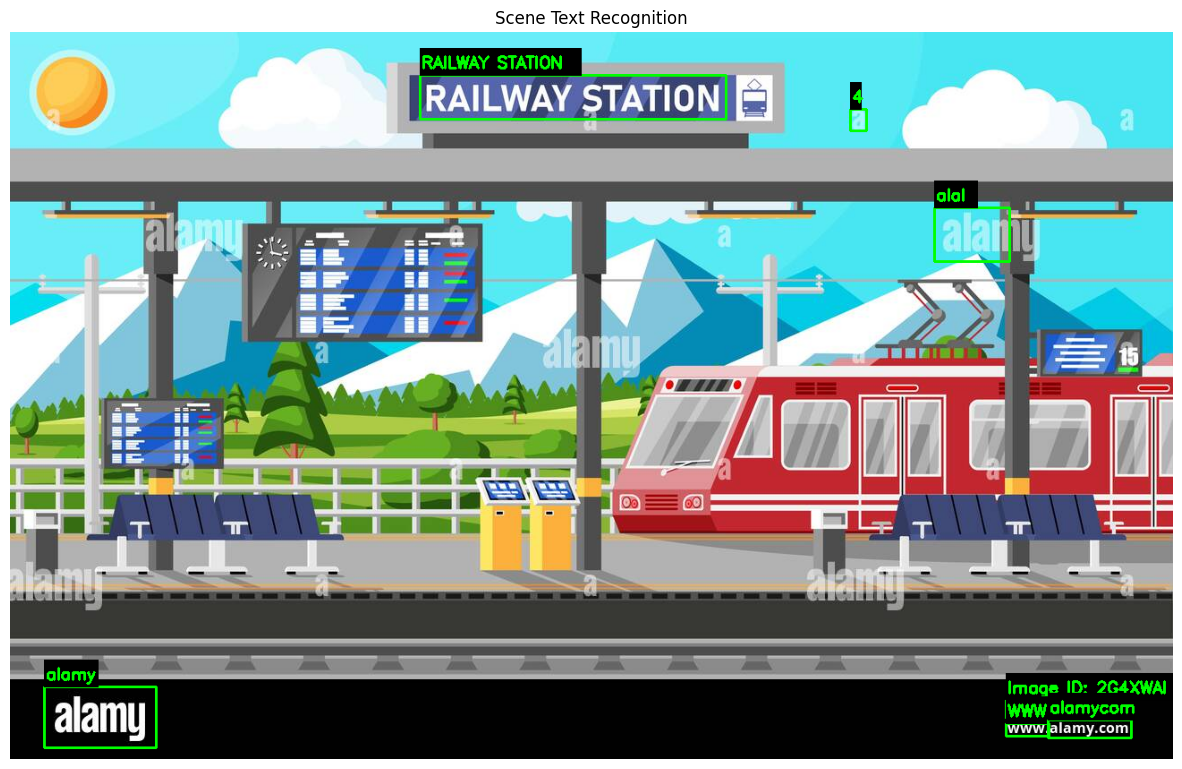

In [5]:
import cv2
import easyocr
import matplotlib.pyplot as plt

# -----------------------
# IMAGE PATH
# -----------------------
image_path = "train.jpg"

# -----------------------
# LOAD IMAGE
# -----------------------
img = cv2.imread(image_path)

if img is None:
    print("Image not found!")
    exit()

# -----------------------
# OCR READER
# -----------------------
reader = easyocr.Reader(['en'])

# -----------------------
# DETECT TEXT
# -----------------------
results = reader.readtext(image_path)

detected_text = ""

# -----------------------
# DRAW RESULTS
# -----------------------
for bbox, text, confidence in results:

    if confidence > 0.50:

        print(f"{text} ({confidence:.2f})")

        detected_text += text + "\n"

        # Coordinates
        top_left = tuple(map(int, bbox[0]))
        bottom_right = tuple(map(int, bbox[2]))

        x1, y1 = top_left
        x2, y2 = bottom_right

        # Green box around detected text
        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Black background for label
        cv2.rectangle(
            img,
            (x1, y1 - 30),
            (x1 + len(text) * 12, y1),
            (0, 0, 0),
            -1
        )

        # Write detected text on image
        cv2.putText(
            img,
            text,
            (x1 + 2, y1 - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

# -----------------------
# SAVE OUTPUT IMAGE
# -----------------------
cv2.imwrite(
    "detected_output.jpg",
    img
)

# -----------------------
# SAVE TEXT FILE
# -----------------------
with open(
    "ocr_output.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(detected_text)

# -----------------------
# DISPLAY RESULT
# -----------------------
plt.figure(figsize=(15,10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Scene Text Recognition")
plt.axis("off")
plt.show()